### INSTALLING NECESSARY FUNCTIONS

In [6]:
!pip install matplotlib
!pip install seaborn
!pip install numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### IMPORTING THE DATASET

In [10]:
df = pd.read_csv(r"C:\Users\USER\Desktop\Customer Churn Analysis\Customer Churn.csv")

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### INSEPCTING DATA

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

##### REPLACING BLANKS WITH 0 AS TENURE IS 0 AND NO TOTAL CHARGES ARE RECORDED

In [16]:
df['TotalCharges'] = df['TotalCharges'].replace(" ","0")
df['TotalCharges'] = df['TotalCharges'].astype("float")

In [17]:
df['customerID'].duplicated().sum()

np.int64(0)

##### CONVERTING 0 AND 1 VALUE OF SENIOR CITIZEN COLUMN INTO YES AND NO

In [18]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [19]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### ANALYSIS

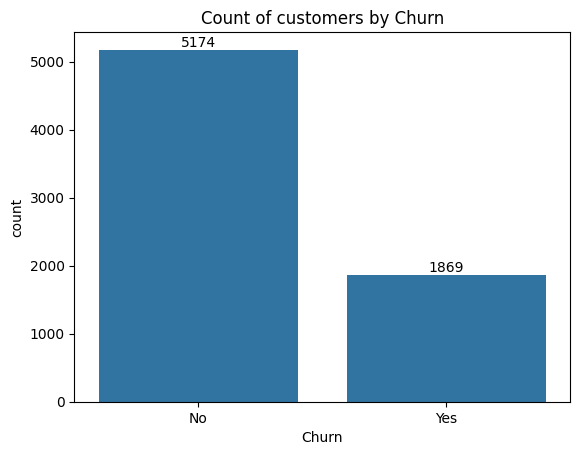

In [20]:
ax = sns.countplot(x = df['Churn'], data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Churn")
plt.show()

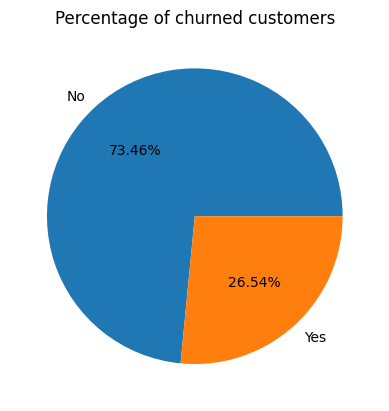

In [21]:
gb = df.groupby('Churn').agg({'Churn':'count'})
plt.title("Percentage of churned customers")
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.show()

##### From the given pie chart we can say that 26.4% of ous customers have churned out. Let's find the reason for this

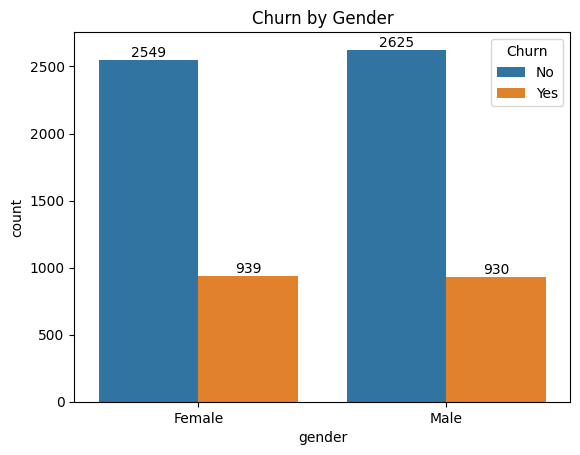

In [22]:
ax = sns.countplot(x = df.gender, data = df, hue = 'Churn')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Gender')
plt.show()

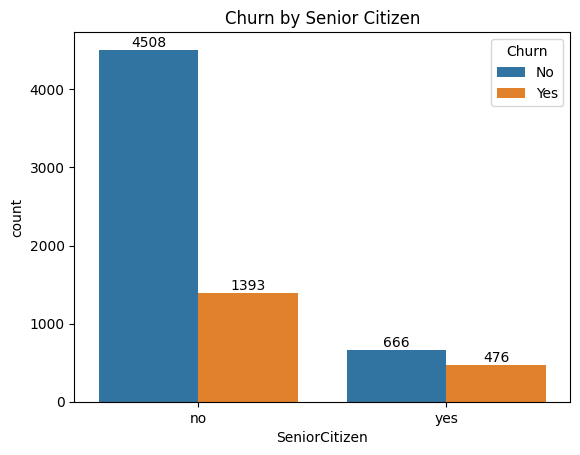

In [23]:
ax = sns.countplot(x = df.SeniorCitizen, data = df, hue = 'Churn')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Senior Citizen')
plt.show()

##### Customers who have used the services for a long time have stayed and customers who have used services in 1st 2nd months have churned

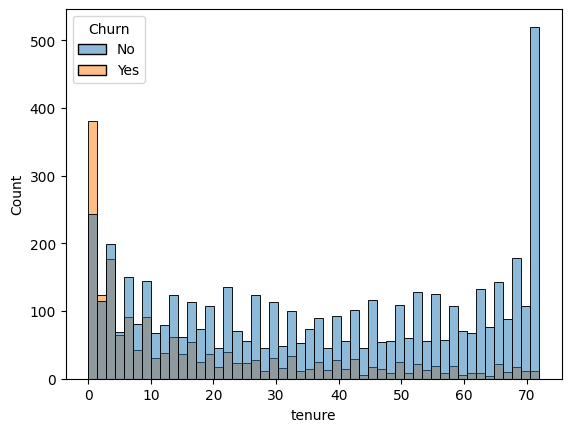

In [24]:
sns.histplot(x = 'tenure', data = df, bins = 50, hue = 'Churn')
plt.show()

##### People who have month on month contract are likely to churn than from those who have yearly contract

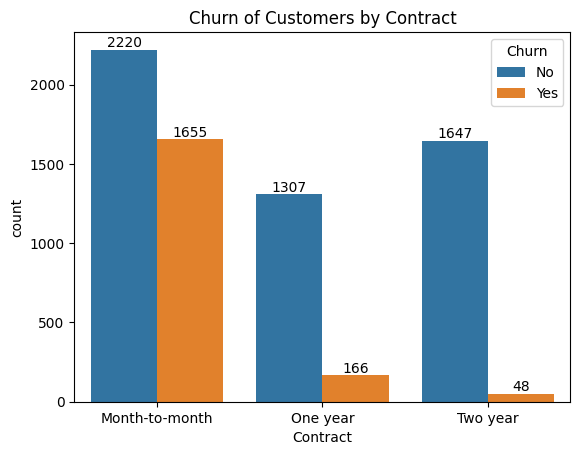

In [25]:
ax = sns.countplot(x = df.Contract, data = df, hue = 'Churn')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn of Customers by Contract')
plt.show()

In [26]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

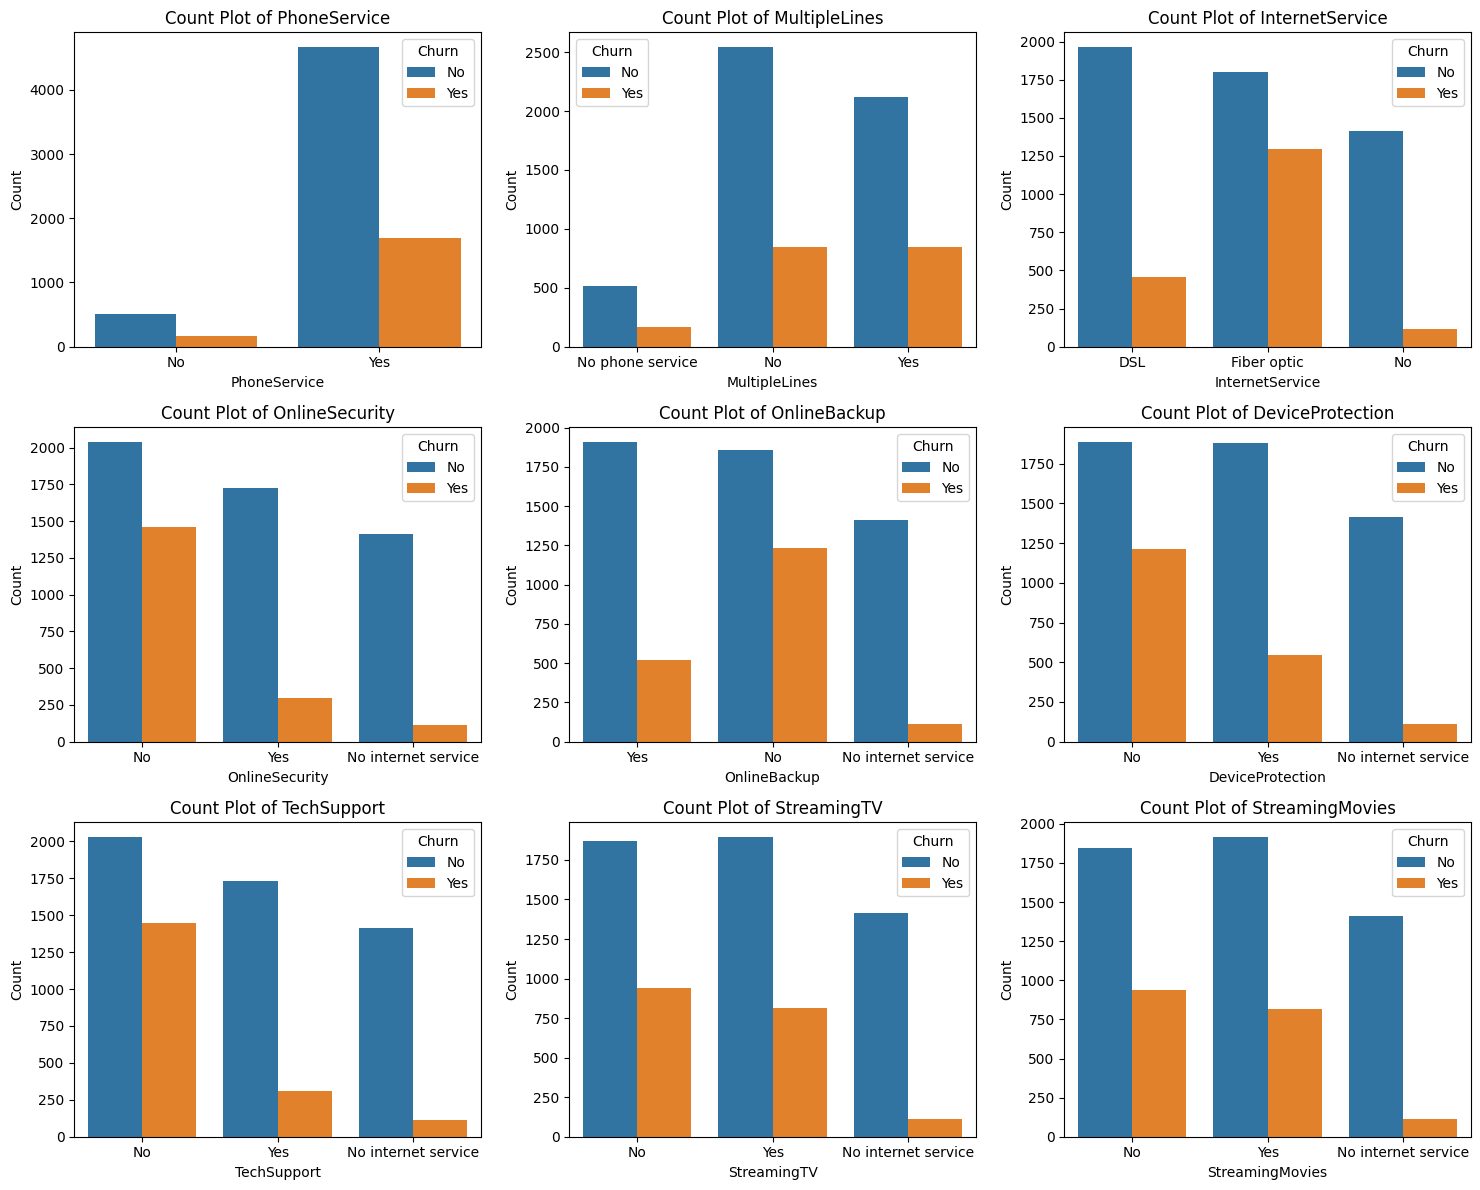

In [27]:
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))

axes = axes.flatten()

for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

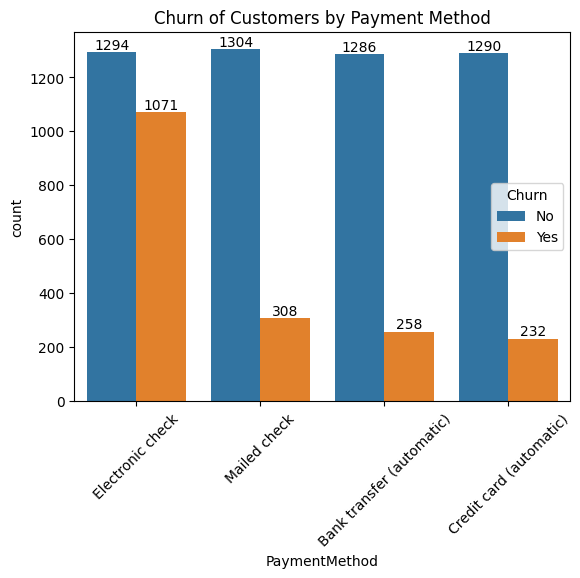

In [28]:
ax = sns.countplot(x = df.PaymentMethod, data = df, hue = df.Churn)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation = 45)
plt.title('Churn of Customers by Payment Method')
plt.show()

##### Customer is likely to churn when they are using electronic check as a payment method

In [30]:
df.shape

(7043, 21)

In [32]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [45]:
df.head

<bound method NDFrame.head of       customerID  gender SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female            no     Yes         No       1   
1     5575-GNVDE    Male            no      No         No      34   
2     3668-QPYBK    Male            no      No         No       2   
3     7795-CFOCW    Male            no      No         No      45   
4     9237-HQITU  Female            no      No         No       2   
...          ...     ...           ...     ...        ...     ...   
7038  6840-RESVB    Male            no     Yes        Yes      24   
7039  2234-XADUH  Female            no     Yes        Yes      72   
7040  4801-JZAZL  Female            no     Yes        Yes      11   
7041  8361-LTMKD    Male           yes     Yes         No       4   
7042  3186-AJIEK    Male            no      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No

In [49]:
df.Churn

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
7038   NaN
7039   NaN
7040   NaN
7041   NaN
7042   NaN
Name: Churn, Length: 7043, dtype: float64

In [55]:
original = pd.read_csv(r"C:\Users\USER\Desktop\Customer Churn Analysis\Customer Churn.csv")

df['Churn'] = original['Churn']

print(df['Churn'].head())
print(df['Churn'].value_counts())

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [57]:
def risk(row):
    if row['Contract'] == 'Month-to-month' and row['tenure'] < 12:
        return "High Risk"
    elif row['MonthlyCharges'] > 80:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_segment'] = df.apply(risk, axis=1)

df['risk_segment'].value_counts()

risk_segment
Low Risk       2902
Medium Risk    2233
High Risk      1908
Name: count, dtype: int64

In [59]:
def action(row):
    if row['risk_segment'] == "High Risk":
        return "Offer Discount"
    elif row['risk_segment'] == "Medium Risk":
        return "Engagement Campaign"
    else:
        return "Upsell"

df['recommended_action'] = df.apply(action, axis=1)

df['recommended_action'].value_counts()

recommended_action
Upsell                 2902
Engagement Campaign    2233
Offer Discount         1908
Name: count, dtype: int64

In [61]:
# Revenue at risk = MonthlyCharges for high-risk customers only
df['revenue_at_risk'] = df['MonthlyCharges']

# Set to 0 for non-high-risk customers
df.loc[df['risk_segment'] != "High Risk", 'revenue_at_risk'] = 0

# Check total revenue at risk
print("Total Revenue at Risk:", df['revenue_at_risk'].sum())

Total Revenue at Risk: 110706.5


In [63]:
df.to_csv("final_churn_dashboard.csv", index=False)

In [64]:
import os
print(os.getcwd())

C:\Users\USER\Desktop\JUPYTER NOTEBOOK
